## ABC renewal

Here we want to show how the interaction between contextual inference and context-specific priors come together to enable strong action recovery when presented with novel or ambigues cues, especially when context is uncertain. 

From Proposal:

Relapse after extinction (cue reactivity)

Illustrating how shifts in inferred context can re-express previously learned policies, leading to strong recovery of action.
-	The idea was to learn ‘drug cue and use action’ in A, extinction in B. Then C is an ambiguous context, e.g. mix of contexts or has slight cues in it, which would cause relapse. 
-	Here, ideally, we need ability to perceive cues. Also, not clear how we implement an ambiguous context exactly.

In animal experiments novel contexts are usually instantiated as a unique context C which is clearly perceivable as unique. 

If I let the agent learn cues, I do get ABC renewal. This effect however appears to be driven by the stronger extinction during B, not the higher rate of lever pressing. So this is not exactly what we are after. Write up like this and send to Stefan. 




## Classes

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.special as scp
import json
# import jsonpickle
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)


## Functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.special as scp
import json
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
from statannotations.Annotator import Annotator

np.set_printoptions(suppress=True)
sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')


class Agent():

	def __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 prior_color_cue = None,
				 learn_cues = False
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations

  
		self.state_transition_matrix = state_transition_matrix
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility
		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.na = na
		self.nc = nc
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])

		self.learn_cues = learn_cues

		if learn_cues:
			self.prior_color_cue_counts = np.zeros([self.TAU, self.T] + list(prior_color_cue.shape))
			self.prior_color_cue_counts[0,:] = prior_color_cue[None,:,:]
			self.prior_color_cue = np.zeros(self.prior_color_cue_counts.shape)
			self.prior_color_cue[0,:] = (prior_color_cue / prior_color_cue.sum(axis=0)[None,:])[None,:]
			
		else:
			self.prior_color_cue = np.zeros([self.TAU, self.T] + list(prior_color_cue.shape))
			self.prior_color_cue[:,:,:,:] = (prior_color_cue / prior_color_cue.sum(axis=0))[None,None,:,:]

		self.background_color_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.observation_generation_matrix = observation_generation_matrix


	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,None]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility

		# print(tau,t,self.utility)
		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):
		if tau == 1:
			pass
		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
			
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies
	

	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context, background_color):
	
		# print(tau,t)
		# context-specific policy likelihood
		
		color_surprise = self.ln(self.prior_color_cue[tau,t,background_color])
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


		else:
			outcome_surprise = np.array([0]*self.nc)
			policy_entropy   = np.array([0]*self.nc)
			policy_surprise  = np.array([0]*self.nc)

		
		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)  + color_surprise #+ cs_surprise
						   
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))


		if self.debug:
			print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			print('outcome_surprise')
			print(outcome_surprise.round(3))
			print('policy_entropy')
			print(policy_entropy.round(3))
			print('policy_surprise')
			print(policy_surprise.round(3))
			print('color_surprise')
			print(color_surprise.round(3))
			print('prior_context')
			print(self.ln(prior_context).round(3))
			print('posterior context')
			print(posterior_context.round(3))
		
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		self.background_color_surprise[tau,t] = color_surprise

		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime


	def update_beliefs_prior_color_cue(self, t, tau, background_color, posterior_context):
		
		alphas = self.prior_color_cue_counts[tau,t].copy()
		alphas_prime = alphas.copy()
		alphas_prime[background_color,:] += posterior_context
		self.prior_color_cue_counts[tau+1] = alphas_prime[None,:,:]
		posterior_predictive_color_cue = self.digamma_approximation(alphas_prime)
		self.prior_color_cue[tau+1] = posterior_predictive_color_cue[None,:,:]


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		
		pol_ind = self.linear_ind(self.actions[tau])[0]
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()
		alphas_prime[pol_ind,:] += posterior_context
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs(self, t, tau, state, reward, action, observation, background_color):
		
		posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context, background_color)


		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)

			if self.learn_cues:
				self.update_beliefs_prior_color_cue(t, tau, background_color, posterior_context)

		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")


			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies.round(3))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies.round(3))
			
			print(f"\nposterior_context:")
			print(posterior_context.round(3))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")
				
				print(f"prior_rewards")
				for k in range(self.nc):
					print(self.prior_rewards[tau,t,:,:,k].round(3))

				if self.learn_cues:
					print(f"\nbackground color counts:")
					print(f"color: {background_color}")
					print(f"\n{self.prior_color_cue_counts[tau,t].round(3)}")


	def sample_action(self,t,tau):

		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
		
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None,
				 color_cue_context_mapping = None):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.zeros([TAU,T],dtype=int)
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)
		self.background_color = np.zeros([TAU,T], dtype=int)
		
		self.color_cue_context_mapping = color_cue_context_mapping
		self.nbc = color_cue_context_mapping.shape[0]

		self.TAU = TAU
		self.T = T
		self.nb = n_bandits

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no


		if training_protocol is None:
			self.training_protocol = np.repeat(np.arange(self.number_reward_regimes),\
											   np.ceil(self.TAU/self.number_reward_regimes))[:self.TAU]
		else:
			self.training_protocol = training_protocol

	
	def sample_reward(self, t, tau, state):
		self.rewards[tau,t] = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		return self.rewards[tau,t]
	
 
	def sample_background_color(self, t, tau):
		self.background_color[tau,:] = np.random.choice(self.nbc, p=self.color_cue_context_mapping[:, self.training_protocol[tau]])
		return self.background_color[tau,t]


	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=self.B[:,self.states[tau, t-1], action])
		
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau, starting_state=2):
		self.states[tau,0] = starting_state
		return starting_state


class World():


	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr


	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]


	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau, starting_state=self.environment.nb)
					background_color = self.environment.sample_background_color(t, tau)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)
					background_color = self.environment.background_color[tau,t]

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state)


				
				self.agent.update_beliefs(t, tau, state, reward, action, observation, background_color)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)

				# if t == self.T-1:
				#     perc = self.agent.perc
				#     for c in range(perc.k):
				#         print(f"\n\ntrial: {tau}, t: {t}, context: {c}")
				#         print(f"action: {action}, reward: {reward}")
				#         print(f"\npost_states:\n{perc.posterior_states[tau,t,:,:,action,c]}")
				#         print(f"\nprior_context:\n{perc.prior_context[tau,t].round(3)}")
				#         print(f"\nposterior_context:\n{perc.posterior_context[tau,t].round(3)}")
				#         print(f"\nprior_rewards:\n{perc.prior_rewards_counts[tau+1,t,:,:,c].round(3)}")
				#         print(f"\nprior_policies:\n{perc.prior_policies_counts[tau+1,t,:,c].round(3)}")
				
				#     if tau==103:
				#         a=0


#####



def run_simulation(h=1000, trials_per_context = [2,2], TAU=4, rep=1, na=2, nb=2, ns=3, no=3,\
    			   nr=3, nc=2, T=2, approx_pred_pol = True, approx_pred_rew = True,\
				   utility = np.array([0.98,0.01, 0.01]), Rho = None, debug=False,\
                   context_volatility=0.98, contexts=None, learn_cues=True, prior_color_cue=None):
	
	
	'''           define policies            '''
	npi = na**(T-1)
	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*nb + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(nb+1)]*nb).transpose([1,2,0])
	state_transition_matrix[:,-1,:] = np.eye(nb+1)[:,:-1]

	state_transition_matrix = np.zeros([ns,ns,na])


	for b in range(nb):
		state_transition_matrix[b,:,b] = 1
	
	'''          define p(o_t|s_t)            '''
	
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.05, size = counts_prior_rewards.shape)
	
	# bias = 1
	# init_counts = np.ones([nr,nb+1])
	# init_counts[0,0] = bias
	# init_counts[1,1:] = bias
	# init_counts[:,-1] = [1,1,100]
	# counts_prior_rewards[:,:,0] = init_counts


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.9] + [1-0.9]*(nc-1))

	p = 0.9
	q = 1-p


	'''       define prior over background color cue        '''
	if prior_color_cue is None:
		prior_color_cue = np.ones([3,nc]) + np.random.uniform(low=0,high=0.05, size = [3,nc])

	'''       define observation context mapping                          '''
	color_cue_map = np.eye(3)

	'''   p(c_t|c_t-1)'''
	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(np.isclose(context_transition_matrix.sum(axis=0), 1)))

	'''   define Env training protocol    '''

	training_protocol = []
	for phase in range(nc):
		training_protocol += [phase]*trials_per_context[phase]
	training_protocol = np.array(training_protocol)

	'''   define Env reward generation matrix if not passed as argument'''
	if Rho is None:		
		p_win = 0.9
		Rho = np.zeros([nr,ns,TAU])
		trials = np.insert(np.cumsum(trials_per_context), 0,0)

		training = np.array([[1-p_win, p_win  , 0],\
							 [p_win  , 1-p_win, 0],\
							 [0      , 0      , 1]])
  
		p_win = 1
		extinction = np.array([[p_win, 1-p_win  , 0],\
							   [1-p_win  , p_win, 0],\
							   [0      , 0      , 1]])
		
		contingencies = [training, extinction, extinction]
		
		for t in range(1, trials.size):
			Rho[:,:,trials[t-1]:trials[t]] = contingencies[t-1][:,:,None]
		
	# Plot task setup

	'''Plot state transition matrix'''
	if False:
	
		fig,axes = plt.subplots(1,2,figsize=(10,4))

		for ai, ax,title in zip([0,1], axes, ['$a_1$ = L1', '$a_2$ = L2']):
			ax.xaxis.tick_top()
			sns.heatmap(state_transition_matrix[:,:,ai],annot=True,ax=ax, cbar=False)
			ax.set_xticklabels(['L1','L2','M'],minor=False);
			ax.set_yticklabels(['L1','L2','M'])
			ax.set_title(title);

		'''Plot likelihood matrix'''
	
		fig, ax = plt.subplots()
		ax = sns.heatmap(prior_rewards[...,0],cbar=False,annot=True)
		ax.set_xticklabels(['L1','L2','M'],minor=False)
		ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
		ax.set_title('Reward generation beliefs')


		'''Plot Environment reward generation matrix'''

		fig,axes = plt.subplots(1,2,figsize=(10,4))
		sns.heatmap(Rho[:,:,0],annot=True,ax=axes[0], cbar=False)
		sns.heatmap(Rho[:,:,-1],annot=True,ax=axes[1], cbar=False)
		for ai, ax,title in zip([0,1], axes, ['Reward Regime 1', 'Reward Regime 2']):
			ax.xaxis.tick_top()
			ax.set_xticklabels(['L1','L2','M'],minor=False)
			ax.set_yticklabels(['$r_1$', '$r_2$', '$r_3$'])
			ax.set_title(title)


	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = nb,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						color_cue_context_mapping = color_cue_map,
						no=no)

	agent = Agent(
			state_transition_matrix,
			utility,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			prior_color_cue = prior_color_cue,
			learn_cues = learn_cues
			)

	world = World(agent, env)

	world.simulate_experiment()

	return world 


def run_cue_reactivity_simulations(learn_cues=False, hs=np.array([1,10,1000]), context_volatility=0.99, utility=np.array([0.025,0.95,0.025]),
                                   trials_per_context=[10,5,5],na=2, nr=3, nc=2, nsims=1, TAU=20, T=2, debug=False,\
                                   contexts=["A","B","C"], sim_name=None, prior_color_cue=None, block_size=20):


	nb = na
	ns = nb + 1
	no = ns
	npi = na**(T-1)
	nc = len(contexts)


	"""agent params"""
	# hs = np.array(hs)
	utilities = np.array([utility])
	agent_instance = np.arange(nsims)
	context_volatilities = np.array([context_volatility])

	"""environment params"""
	trials_per_context = np.array([trials_per_context])

	## construct list of simulations
	parameter_combinations = product(agent_instance, hs, utilities, trials_per_context, context_volatilities)
	sim_params = []

	for p in parameter_combinations:
		# sim specific params
		pars = {}
		pars["rep"] = p[0]
		pars["h"] = p[1]
		pars["utility"] = p[2]
		pars["trials_per_context"] = p[3]
		pars["context_volatility"] = p[4]


		## global params
		pars["TAU"] = TAU
		pars["na"] = na
		pars["nb"] =  nb
		pars["ns"] = ns
		pars["no"] = no
		pars["nr"] =  nr
		pars["nc"] = len(contexts)
		pars["contexts"] = contexts 
		pars["T"] = T
		pars["debug"] = debug
		pars["learn_cues"] = learn_cues
		pars["prior_color_cue"] = prior_color_cue
		sim_params.append(pars)



	### run simulations
	print(f"simulations to run: {len(sim_params)}")

	df = { col : [] for col in ["run","habitual_tendency",\
								"utility_0"	,"utility_1","utility_2", "context_volatility",\
								# "context_a","context_b","context_c","context_d", "context_func",\
								# "policy_a","policy_b","policy_c","policy_d","policy_func", "dkl_c1", "dkl_c2",\
								"q_context", "q_policy",\
								# "se_context_a", "se_context_b", "se_context_c", "se_context_d",\
								"habit_c1", "habit_c2", "habit_c3", "preference_a2_c1", "preference_a2_c2", "preference_a2_c3", "failed"]}#,"threshold_c",, "inflection_trial"]} #, "habit_strength_context", "habit_strength_action"
	long_dfs = []
	prior_policies_matrix = {h:[] for h in hs}
	for pi, p in enumerate(sim_params):
		if pi% 250 == 0:
			print(f"just finished sim {pi}")
		
		world = run_simulation(**p)
		agent = world.agent
		
		# Create long format dataframe
		run_arr = np.full(TAU * T, p["rep"])
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		reward_arr = world.environment.rewards.flatten()
		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()
		h_arr = np.full(TAU * T, p["h"])
		context_volatility_arr = np.full(TAU * T, p["context_volatility"])
		utility_0_arr = np.full(TAU * T, p["utility"][0])
		utility_1_arr = np.full(TAU * T, p["utility"][1])
		utility_2_arr = np.full(TAU * T, p["utility"][2])
		n_blocks = TAU // block_size
		block_arr = np.arange(n_blocks).repeat(block_size * T)
		sim_arr = np.full(TAU*T,pi)
		true_context = world.environment.training_protocol.repeat(2)
		habits = np.argmax(world.agent.prior_policies[-1,-1],axis=0)
		habit_c1 = np.full(TAU*T, habits[0])
		habit_c2 = np.full(TAU*T, habits[1])
		habit_c3 = np.full(TAU*T, habits[2])
		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		outcome_surp_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		inferred_context = np.argmax(agent.posterior_context[:,0,:],axis=1)
		nic = np.unique(inferred_context).size
		best_fit = 0
		best_mapping = []

		if nic == 2:
			failed = True
			best_mapping = np.unique(inferred_context)
			best_mapping = np.append(best_mapping, np.setdiff1d(np.arange(nc), best_mapping)[0])
		else:
			failed = False
			for i in range(100):
				mapping = np.random.permutation(nc)
				fit = (mapping[inferred_context] == world.environment.training_protocol).sum()
				if fit > best_fit:
					best_fit = fit
					best_mapping = mapping

		# for c in range(nc):
		for ci, c in enumerate(best_mapping):
			context_post_arr[f"posterior_context_c{ci}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{ci}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{ci}"] = agent.policy_surprise[:,:,c].flatten()
			outcome_surp_arr[f"outcome_surprise_c{ci}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(npi):
				reward_prior_arr[f"reward_s{pi}_c{ci}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
				prior_arr[f"prior_pi{pi}_c{ci}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{ci}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{ci}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"block": block_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"utility_0": utility_0_arr,
			"utility_1": utility_1_arr,
			"utility_2": utility_2_arr,
			"sim":sim_arr,
			"true_context":true_context,
			"failed": np.array([failed]).repeat(TAU*T),
			"habit_c1": habit_c1,
			"habit_c2": habit_c2,
			"habit_c3": habit_c3,
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**outcome_surp_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		long_df = pd.DataFrame(long_df_dict)
		long_dfs.append(long_df)

		prior_policies_matrix[p["h"]].append(agent.prior_policies[-1,-1])

	if sim_name is not None:
		name=sim_name
	else:
		name = f"data_cue_reactivity_{TAU}_util{utilities[0][1]}_context{context_volatilities[0]}"

	prior_policies_matrix = {h: np.array(item).mean(axis=0) for h, item in prior_policies_matrix.items()}
	long_df = pd.concat(long_dfs)
	long_df.to_csv(name + "_long.csv", index=False)
	print(name)

	return long_df,prior_policies_matrix, name


def plot_figures(df_long, prior_policies_matrix, prior_color_cue, dpi=100):

	df_long["h"] = 1/df_long["h"]
	df_long["h"] = df_long["h"].astype("category")

	# failed_agents = df_long[df_long["habit_c2"]== 0].index
	# df_long = df_long.drop(failed_agents)

	nc = df_long.true_context.unique().size
	nh = df_long.h.unique()
	legend_titles = ["Context A\n(training)", "Context B\n(extinction)", "Context C\n(test)"]

	""" OBSEVATION MAPPING PLOT"""
	plt.figure(figsize=(4,3),dpi=dpi)
	g=sns.heatmap(prior_color_cue/prior_color_cue.sum(axis=0),annot=True)
	g.set_title(f"p(cue|context) with \ncontext self-transition prob: {context_volatility}")


	""" PLOT CONTEXT POSTERIOR """
	# fig, axes = plt.subplots(1,k.size, figsize=(11,3),dpi=dpi)
	# plt.tight_layout()
	# # fig, axes = plt.subplots(2,5, figsize=(10,6))
	# for ai, ax in enumerate(axes):
	# 	for ci in range(nc):
	# 		g = sns.lineplot(ax=ax, data=df_long.query(f"t==0 & h == {k[ai]}"), x="tau", y=f"posterior_context_c{ci}", errorbar="se",label=legend_titles[ci])
	# 	if ai == axes.size-1:
	# 		g.legend(bbox_to_anchor=(1.05,1))
	# 	else:
	# 		g.legend_=None
	# 	ax.set_title(fr"$h$: {k[ai]}",fontsize=16)
	# 	ax.set_ylabel("Posterior contexts",fontsize=16)
	# 	ax.set_ylim([0,1])
	# 	ax.set_xlabel("trial")


	fig, axes = plt.subplots(1,nc, figsize=(9,3),dpi=dpi)
	plt.tight_layout()
	plt.subplots_adjust(wspace=0.3)

	legend_titles = ["Context A\n(training)", "Context B\n(extinction)", "Context C\n(test)"]
	for ai, ax in enumerate(axes):
		sns.lineplot(ax=ax, data=df_long.query(f"t==0"), x="tau", y=f"posterior_context_c{ai}", hue="h",errorbar="se", palette="viridis")
		ax.set_title(legend_titles[ai],fontsize=16)
		if ai == axes.size-1:
			ax.legend(bbox_to_anchor=(1.05,1), title=r"$h$")
		else:
			ax.legend_=None
		# ax.set_title(fr"$h$: {k[ai]}",fontsize=16)
		ax.set_ylabel("Posterior context",fontsize=16)
		ax.set_ylim([0,1.01])
		ax.set_xlabel("trial", fontsize=16)


	""" PLOT LEVER PRESS POSTERIOR"""
	df_long["posterior_entropy"] = -np.nansum(df_long[[f"posterior_context_c{c}" for c in range(len(contexts))]] * np.log(df_long[[f"posterior_context_c{c}" for c in range(len(contexts))]] + 1e-10), axis=1)
	
	fig, axes = plt.subplots(1,2, figsize=(8,3),dpi=dpi)
	plt.tight_layout()
	plt.subplots_adjust(wspace=0.3)

	ax = axes[0]
	plt.figure(dpi=dpi)
	sns.lineplot(ax=ax, data=df_long.query("t==0"), x="tau", y="posterior_entropy", hue="h", errorbar="se", palette="viridis", linewidth=0.5)
	# ax.set_xlim([158,165])
	# ax.set_ylim([0.5,0.65])
	ax.set_ylabel("Context posterior entropy", fontsize=16)
	ax.set_xlabel(r"trial", fontsize=16)

	ax = axes[1]
	g = sns.lineplot(ax=ax, data=df_long.query(f"t==0"), x="tau", y=f"posterior_pi{0}", hue="h", errorbar="se",linewidth=0.5, palette="viridis")
	# ax.set_ylim([0.25,0.4])
	# ax.set_xlim([158,165])
	ax.legend(loc="lower left",title=r"$h$")
	ax.set_ylabel("Posterior of lever press policy",fontsize=16)
	ax.set_xlabel("trial",fontsize=16)
	
	"""ACTION 1 FREQUENCY PLOT """
	plot_df = df_long.copy()
	plot_df["action"] = plot_df["action"].astype("category")
	plot_df = plot_df.groupby(by=["h","run", "block","t"])["action"].value_counts(normalize=True, dropna=False).reset_index()

	plot_df = plot_df.query("action==0 & block >= 7 & t==0")
	display(plot_df)

	plt.figure(dpi=dpi) 
	# palette = sns.color_palette("tab10")
	# palette = sns.color_palette("tab10")[1:] + sns.color_palette("tab10")[:1]
	palette = "Grays"
	# g = sns.boxplot(data=plot_df.query("action==0 & block >= 7"), x="h",y="proportion", hue="block", palette="tab10", boxprops={"alpha":0.6})
	g = sns.barplot(data=plot_df, x="h",y="proportion", hue="block", palette=palette, alpha=0.7, linewidth=0.6,edgecolor="black")
	g = sns.stripplot(data=plot_df, x="h",y="proportion", hue="block",dodge=True,palette=palette, linewidth=0.5, edgecolor="black", alpha=0.8,size=2)

	g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context B (extinction)", "Context C (test)"], fontsize=16, title=None, loc="upper left")
	g.set_ylabel("Frequency of lever press", fontsize=16)
	g.set_xlabel(r"Habitual tendency $h$", fontsize=16)
	g.set_ylim([0,1])
 
	"""   Learned policy prior    """
	
	fig, axes = plt.subplots(1,nh.size, figsize=(16,2),dpi=dpi)

	plt.subplots_adjust(wspace=0.35)
	for ax,h in zip(axes, 1/nh.to_numpy()):
		sns.heatmap(ax=ax, annot=True, data=prior_policies_matrix[h], vmin=0, vmax=1, cmap="Grays_r")
		ax.set_title(fr"$h$: {1/h}", fontsize=14)
		ax.set_ylabel("Policy", fontsize=14)
		ax.set_xlabel("Context", fontsize=14)
	fig.suptitle("Learned $p(\pi|c)$", fontsize=16, y=1.15)
	

	"""   ABC renewal magnitude    """


	df = df_long.copy()
	# df["action"] = df["action"].astype("category")
	# df = df.groupby(by=["h","run","block","t"])["action"].value_counts(normalize=True,dropna=False)
	# df = (df.loc[:,:,8,0,0] - df.loc[:,:,7,0,0]).to_frame()
	# # display(df.loc[np.isnan(df["proportion"])])
	# plt.figure(dpi=dpi)
	# g = sns.barplot(data=df, x="h",y="proportion", palette="viridis")
	# g = sns.stripplot(data=df, x="h", y="proportion", palette="viridis", linewidth=0.5, edgecolor="black", alpha=0.8,size=2)
	# g.set_ylim([0,1])
	# g.set_ylabel("Lever press difference\ncontext C - context A", fontsize=16)
	# g.set_xlabel(r"Habitual tendency $h$", fontsize=16)


	df = df.groupby(["h", "run", "block", "t"])["action"].value_counts(normalize=True, dropna=False)

	df = (df.loc[:,:,8,0,0] - df.loc[:,:,7,0,0]).to_frame().reset_index()

	# Check normality
	print("\nNormality (Shapiro-Wilk):")
	normal = True
	for h, g in df.groupby("h"):
		x = g["proportion"].dropna()
		W, p = stats.shapiro(x)
		print(f"  h={h}: W={W:.3f}, p={p:.4g}")
		normal &= p > 0.05

	groups = [g["proportion"].dropna() for _, g in df.groupby("h")]

	# Omnibus test + post-hoc
	if normal:
		stat, p = stats.f_oneway(*groups)
		print(f"\nOne-way ANOVA: F={stat:.3f}, p={p:.4g}")

		tukey = pairwise_tukeyhsd(df["proportion"], df["h"])
		print("\nTukey HSD:")
		print(tukey)

		pairs = [
			(tukey._multicomp.groupsunique[i],
			tukey._multicomp.groupsunique[j])
			for i, j in tukey._multicomp.pairindices
		]
		pvals = tukey.pvalues

	else:
		stat, p = stats.kruskal(*groups)
		print(f"\nKruskal-Wallis: H={stat:.3f}, p={p:.4g}")

		posthoc = sp.posthoc_dunn(df, val_col="proportion", group_col="h")

		print("\nDunn's post-hoc test:")
		print(posthoc)

		pairs = [
			(a, b)
			for i, a in enumerate(posthoc.index)
			for b in posthoc.columns[i + 1:]
		]
		pvals = [posthoc.loc[a, b] for a, b in pairs]


	plt.figure(dpi=dpi)
	ax = sns.barplot(data=df, x="h", y="proportion", palette="viridis", errorbar="se")
	sns.stripplot(data=df, x="h", y="proportion", palette="viridis", linewidth=0.5, edgecolor="black", alpha=0.8, size=2)

	ax.set_ylim([0, 1])
	ax.set_ylabel("Lever press difference\ncontext C - context A", fontsize=16)
	ax.set_xlabel(r"Habitual tendency $h$", fontsize=16)

	# significance stars
	annotator = Annotator(ax, pairs, data=df, x="h", y="proportion")
	annotator.configure(
		test=None,
		text_format="star",
		loc="outside",
		verbose=0
	)
	annotator.set_pvalues_and_annotate(pvals)
		



<>:1045: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1045: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_298484/2924323449.py:1045: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  fig.suptitle("Learned $p(\pi|c)$", fontsize=16, y=1.15)


simulations to run: 150
just finished sim 0


data_cue_reactivity_170_nonambiguous_certain_learn_cues


,h,run,block,t,action,proportion
43,0.001,0,7,0,0.0,0.10
49,0.001,0,8,0,0.0,0.25
97,0.001,1,7,0,0.0,0.10
103,0.001,1,8,0,0.0,0.20
152,0.001,2,7,0,0.0,0.00
...,...,...,...,...,...,...
7987,1.000,47,8,0,0.0,0.05
8036,1.000,48,7,0,0.0,0.00
8041,1.000,48,8,0,0.0,0.35
8089,1.000,49,7,0,0.0,0.10


/tmp/ipykernel_298484/2924323449.py:1030: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 2
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context B (extinction)", "Context C (test)"], fontsize=16, title=None, loc="upper left")
/tmp/ipykernel_298484/2924323449.py:1113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="h", y="proportion", palette="viridis", errorbar="se")



Normality (Shapiro-Wilk):
  h=0.001: W=0.964, p=0.2057
  h=0.1: W=0.907, p=0.02561
  h=1.0: W=0.811, p=0.006937

Kruskal-Wallis: H=1.505, p=0.4711

Dunn's post-hoc test (Bonferroni corrected):
          0.001     0.100     1.000
0.001  1.000000  0.488739  0.798416
0.100  0.488739  1.000000  0.773511
1.000  0.798416  0.773511  1.000000


/tmp/ipykernel_298484/2924323449.py:1114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="h", y="proportion", palette="viridis", linewidth=0.5, edgecolor="black", alpha=0.8, size=2)


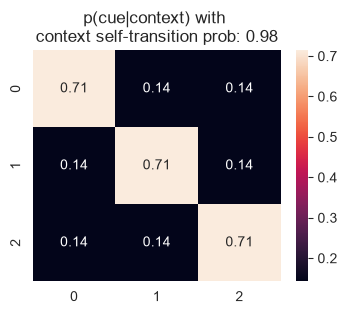

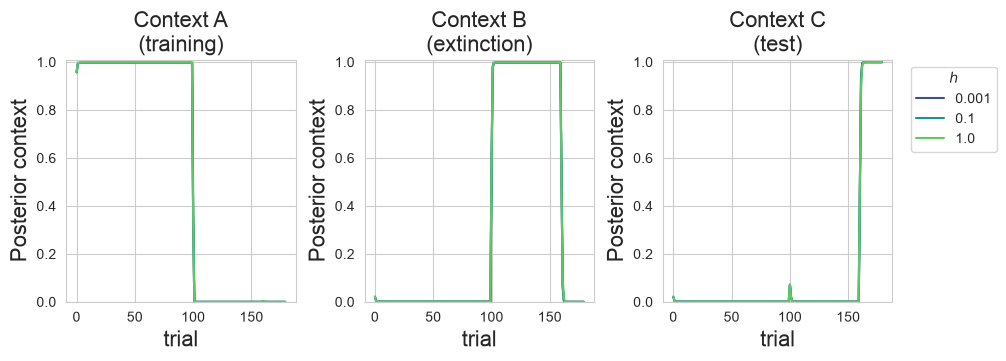

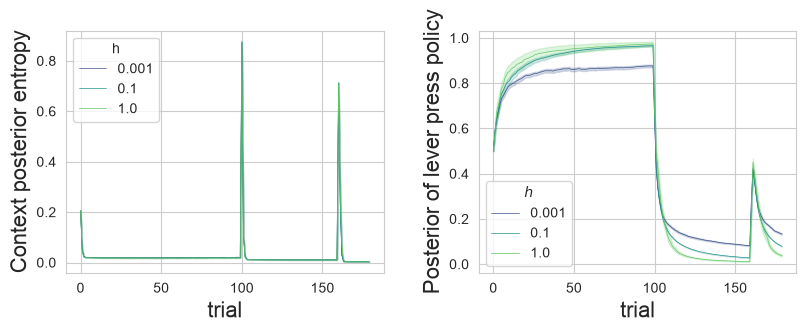

<Figure size 640x480 with 0 Axes>

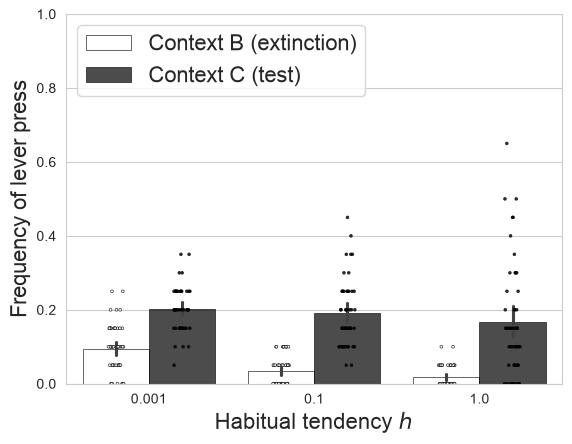

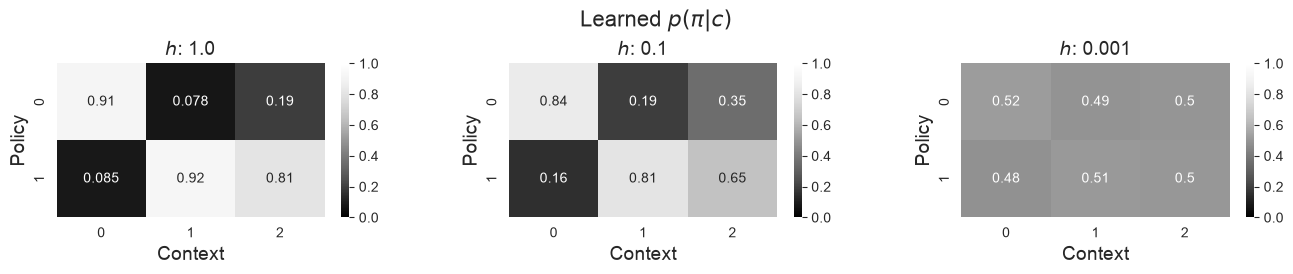

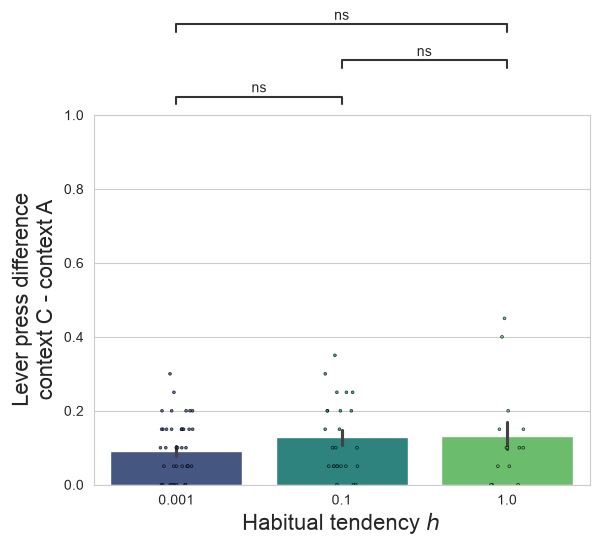

In [19]:

np.random.seed(3)
dpi = 100
hs = np.array([1, 10, 1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.98
block_size = 20
trials_per_context = np.array([5,3,1])*block_size

utility = np.array([0.025,0.95	, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = True

prior_color_cue = np.array([[5,  1,  1],
							[1,  5,  1],
							[1,  1,  5]])
nsims= 50

name = "data_cue_reactivity_170_nonambiguous_certain_learn_cues"

df_long, prior_matrix, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                   context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                   nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues, block_size=block_size)

df_long = pd.read_csv(name + "_long.csv")
plot_figures(df_long, prior_matrix, prior_color_cue, dpi=dpi)



simulations to run: 150
just finished sim 0


data_cue_reactivity_170_ambiguous_certain_learn_cues


,h,run,block,t,action,proportion
43,0.001,0,7,0,0.0,0.15
49,0.001,0,8,0,0.0,0.40
97,0.001,1,7,0,0.0,0.20
103,0.001,1,8,0,0.0,0.25
151,0.001,2,7,0,0.0,0.25
...,...,...,...,...,...,...
7987,1.000,47,8,0,0.0,0.20
8035,1.000,48,7,0,0.0,0.10
8041,1.000,48,8,0,0.0,0.40
8089,1.000,49,7,0,0.0,0.35


/tmp/ipykernel_298484/2924323449.py:1030: UserWarning: Mismatched number of handles and labels: len(handles) = 4 len(labels) = 2
  g.legend(handles=g.get_legend_handles_labels()[0], labels=["Context B (extinction)", "Context C (test)"], fontsize=16, title=None, loc="upper left")
/tmp/ipykernel_298484/2924323449.py:1113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="h", y="proportion", palette="viridis", errorbar="se")



Normality (Shapiro-Wilk):
  h=0.001: W=0.956, p=0.07261
  h=0.1: W=0.958, p=0.1407
  h=1.0: W=0.939, p=0.03832

Kruskal-Wallis: H=20.639, p=3.299e-05

Dunn's post-hoc test (Bonferroni corrected):
          0.001     0.100     1.000
0.001  1.000000  0.059433  0.000112
0.100  0.059433  1.000000  0.054715
1.000  0.000112  0.054715  1.000000


/tmp/ipykernel_298484/2924323449.py:1114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="h", y="proportion", palette="viridis", linewidth=0.5, edgecolor="black", alpha=0.8, size=2)


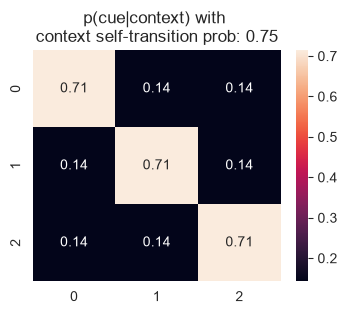

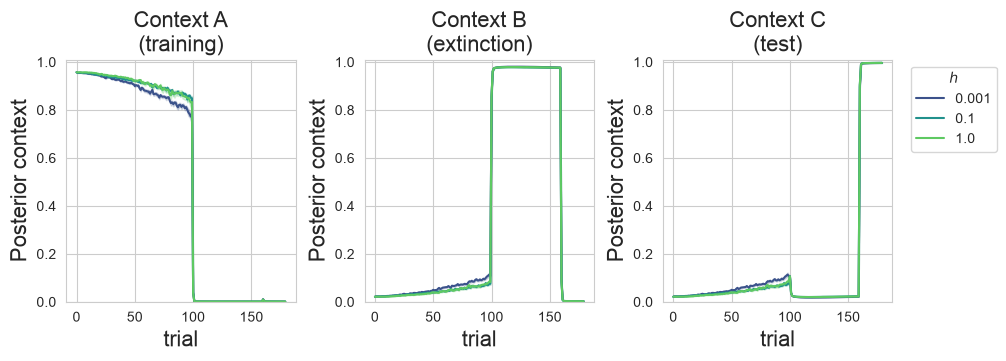

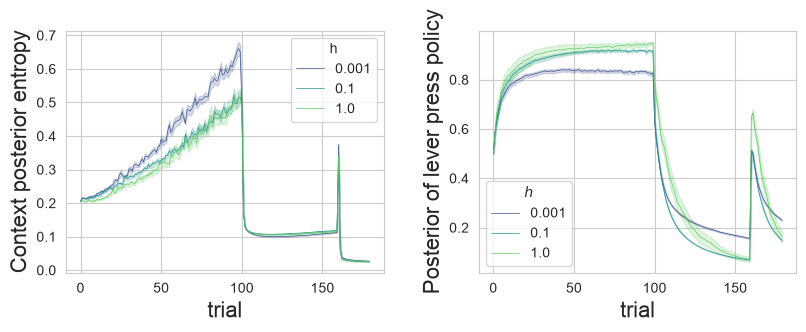

<Figure size 640x480 with 0 Axes>

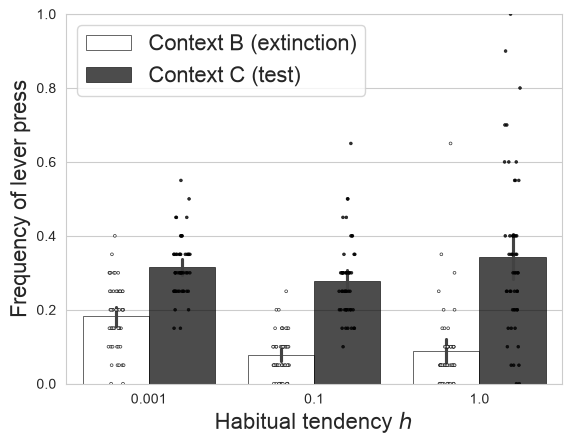

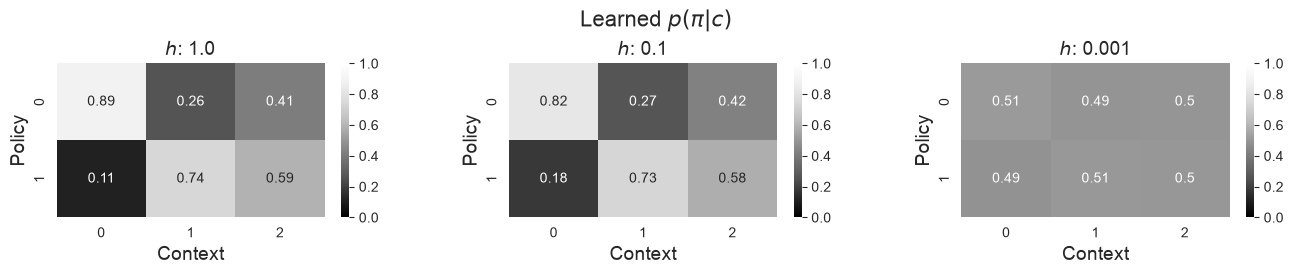

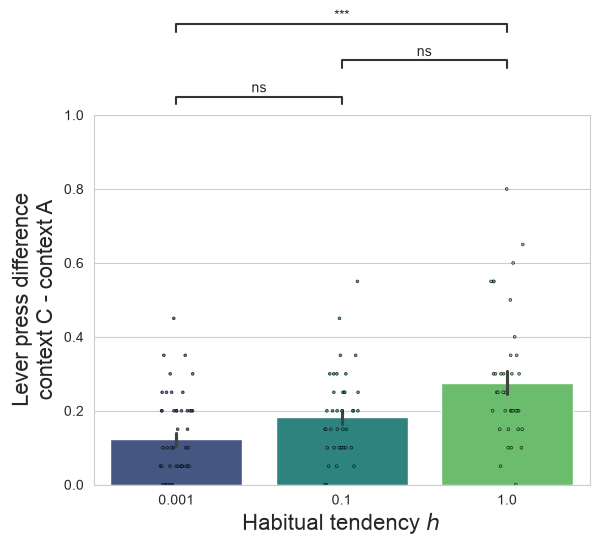

In [20]:

np.random.seed(3)
dpi = 100
hs = np.array([1, 10, 1000])#[1,2,3,4,5,6,7,8,9,10,100])
context_volatility = 0.75
block_size = 20
trials_per_context = np.array([5,3,1])*block_size

utility = np.array([0.025,0.95, 0.025])
TAU = np.array(trials_per_context).sum()
contexts = ["A","B","C"]
learn_cues = True

prior_color_cue = np.array([[5,  1,  1],
							[1,  5,  1],
							[1,  1,  5]])
nsims= 50

name = "data_cue_reactivity_170_ambiguous_certain_learn_cues"

df_long, prior_matrix, name = run_cue_reactivity_simulations(debug=False, sim_name=name, TAU=TAU, hs=hs, utility=utility,\
                                                    context_volatility=context_volatility, trials_per_context=trials_per_context,\
                                                    nsims=nsims, contexts=contexts, prior_color_cue=prior_color_cue, learn_cues=learn_cues, block_size=block_size)

													
df_long = pd.read_csv(name + "_long.csv")
plot_figures(df_long, prior_matrix, prior_color_cue, dpi=dpi)

